![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### **Información adicional del diccionario de datos:**

Bike sharing systems are new generation of **traditional bike rentals** where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues. 

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

| Variable Name | Role | Type | Description | Units | Missing Values |
|---|---|---|---|---|---|
| instant | ID | Integer | record index | | no |
| dteday | Feature | Date | date | | no |
| season | Feature | Categorical | 1:winter, 2:spring, 3:summer, 4:fall | | no |
| yr | Feature | Categorical | year (0: 2011, 1: 2012) | | no |
| mnth | Feature | Categorical | month (1 to 12) | | no |
| hr | Feature | Categorical | hour (0 to 23) | | no |
| holiday | Feature | Binary | weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule) | | no |
| weekday | Feature | Categorical | day of the week | | no |
| workingday | Feature | Binary | if day is neither weekend nor holiday is 1, otherwise is 0 | | no |
| weathersit | Feature | Categorical | 1: Clear, Few clouds, Partly cloudy, Partly cloudy | | no |
| temp | Feature | Continuous | Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale) | C | no |
| atemp | Feature | Continuous | Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale) | C | no |
| hum | Feature | Continuous | Normalized humidity. The values are divided to 100 (max) | | no |
| windspeed | Feature | Continuous | Normalized wind speed. The values are divided to 67 (max) | | no |
| casual | Other | Integer | count of casual users | | no |
| registered | Other | Integer | count of registered users | | no |
| cnt | Target | Integer | count of total rental bikes including both casual and registered | | no |

### Datos prestamo de bicicletas

In [230]:
import warnings
warnings.filterwarnings('ignore')

In [231]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [232]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,21


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [233]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [234]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [235]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  total       10886 non-null  int64  
 11  hour        10886 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 1.1 MB


In [236]:
bikes.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000


In [237]:
bikes.groupby('season').total.max()

season
1    801
2    873
3    977
4    948
Name: total, dtype: int64

In [238]:
bikes.groupby('hour').total.max()

hour
0     283
1     168
2     119
3      66
4      28
5      57
6     213
7     596
8     839
9     414
10    539
11    647
12    757
13    729
14    730
15    724
16    783
17    970
18    977
19    743
20    551
21    584
22    502
23    256
Name: total, dtype: int64

### **Hallazgos**

1. **Season**
- La variable ``season`` tiene la posibilidad de tomar los siguientes valores: ``1:winter``, ``2:spring``, ``3:summer``, 4:fall, correspondientes a las diferentes estaciones del año.
- Al analizar el promedio de bicicletas rentadas agrupandolo por la variable ``season``, es posible observar que el número de bicicletas rentadas es similar para las categorías 2, 3 y 4; sin embargo, para la categoría ``1: winter``, el promedio bicicletas rentadas se reduce en aproximadamente un 50%. Esto tiene sentido dado que los viajes al aire libre en invierno no son tan comunes debido a la exposición a temperaturas extremas y condiciones que pueden poner en peligro la vida de las personas (carreteras o vías con capas de hielo).
- La estación con el mayor registro de bicicletas rentadas en una hora fue `3:summer` con un total de 977.
2. **Hour**
- Las horas con mayor uso del servicio de renta de bicicletas son las horas de la tarde comenzando desde las 12 hrs hasta las 19 hrs, con un pico de actividad entre las 16 y las 18 horas.
- Existe otro pico de actividad durante el día que corresponde a las 8 hrs, donde se encuentra un pico máximo de 839 servicios rentados.
- A partir de las 19 hrs se presenta una baja de actividad significativa.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

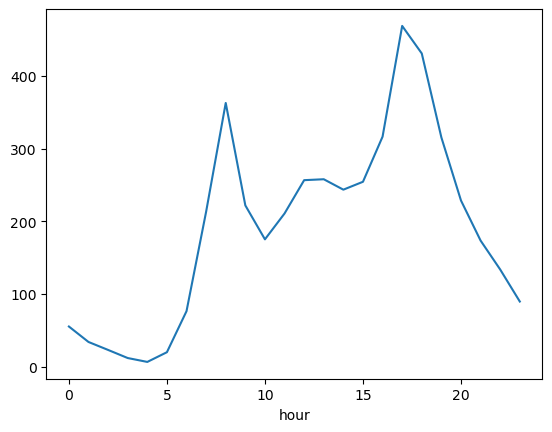

In [239]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()


<Axes: xlabel='hour'>

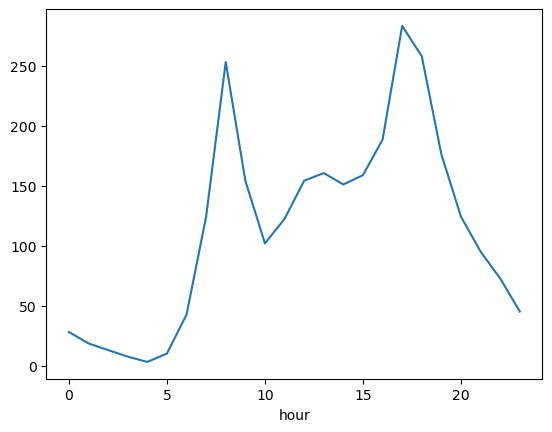

In [240]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season']==1].groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

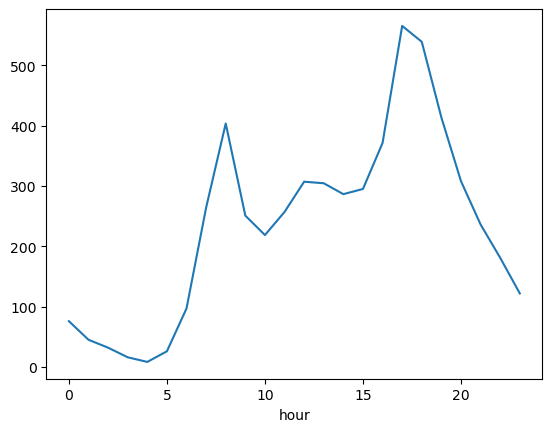

In [241]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season']==3].groupby('hour').total.mean().plot()

### **Hallazgos**

- Resulta evidente que el comportamiento de renta a lo largo del día se mantiene para las diferentes estaciones exceptuando en invierno donde se logra identificar una reducción significativa del pico de renta alrededor de las 8hrs.
- La cantidad promedio de renta por hora disminuye significativamente durante el invierno.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [242]:
# Celda 3
bikes_dummies = pd.get_dummies(bikes[['hour', 'season']], columns=['season'], drop_first = True) # Codificación de variables categóricas

X = bikes_dummies # Variables predictoras
y = bikes['total'] # Variable respuesta

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) # Split de los datos en entrenamiento y prueba

# Regresión lineal

lr = LinearRegression() # Modelo de regresión lineal
lr.fit(X_train, y_train) # Entrenamiento del modelo

# Métricas de evaluación

# 1. R^2
print('R^2 en el set de entrenamiento: ', lr.score(X_train, y_train))
print('R^2 en el set de prueba: ', lr.score(X_test, y_test))

# 2. MSE
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Resultados de las métricas de evaluación
print('MAE: ', mean_absolute_error(y_test, y_pred))

R^2 en el set de entrenamiento:  0.22604951385989513
R^2 en el set de prueba:  0.21636575170625916
MAE:  119.02001834187203


### **Hallazgos**

1. **Métricas:**
- Un R^2 = 0.22 implica que el modelo solo alcanza a explicar el 22% de la variabilidad del número de bicicletas que se rentaron, dejando un total de 78% sin explicar. Debido a los dos picos que se presentan a las 8 hrs y entre las 16 a 18 hrs, un modelo lineal no logra capturar la forma y por ende no lo puede explicar del todo.
- MAE: Usar el Mean absolute error nos permite Penalizar todos los errores por igual, lo que ayuda a la interpretabilidad del error. En este caso, el MAE = 119.02 nos indica que en promedio, el modelo se equivoca en un total de 119 bicicletas rentadas por hora.
2. **Limitaciones:**
- La regresión lineal no alcanza a capturar la relación de las variables, la regresión lineal asume una relación constante entre la hora del día y un crecimiento/decrecimiento de la cantidad de bicicletas rentadas. Podemos deducir que no es así dado las series de tiempo generadas en el punto 2.
- El efecto de renta/hora cambia en función a la estación, la regresión lineal no logra captar esta relación.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [243]:
# Celda 4

# Parámetros del árbol de decisión
max_depth = None # nivel de profundidad del árbol
num_pct = 10 # numero de percentiles para dividir las variables
max_features = None # Usa todas las variables disponibles
min_gain = 0.001 # Solo se hace un split si la ganancia de información es mayor a este valor

In [244]:
X1 = bikes[['hour','season']].reset_index(drop=True)
y1 = bikes['total'].reset_index(drop=True)

In [245]:
j1 = 0 

print(X1.columns[j1])

splits_hour = np.percentile(X1.iloc[:,j1], np.arange(0, 100, 100/num_pct).tolist()) # División de la variable 'hour' en percentiles
splits_hour = np.unique(splits_hour) # Eliminar valores duplicados

print(splits_hour)

hour
[ 0.  2.  4.  7.  9. 12. 14. 16. 19. 21.]


In [246]:
k = 5
filter_l = X1.iloc[:,j1] < splits_hour[k] # Filtro para el nodo izquierdo

y1_l = y1.loc[filter_l] # Variable respuesta para el nodo izquierdo
y1_r = y1.loc[~filter_l] # Variable respuesta para el nodo derecho

In [247]:
def mse_nodo(y1):
    if len(y1) == 0:
        return 0
    return ((y1 - y1.mean()) ** 2).mean()

In [248]:
mse_l = mse_nodo(y1_l)
mse_l

22404.882286091048

In [249]:
mse_r = mse_nodo(y1_r)
mse_r

32551.242665177695

In [250]:
# Función para encontrar el mejor split de los features basado en la ganancia de información (Menor MSE)

def best_split(X, y, num_pct = 10):

    nro_features = range(X.shape[1]) # Número de features disponibles

    best_split = [0, 0, 0]  # j, split, gain

    for j in nro_features: # j es el índice de la variable a evaluar

        valores_unicos = np.unique(X.iloc[:, j]) # Valores únicos de la variable j

        if len(valores_unicos) <= num_pct: # Si la variable contiene menos valores únicos que el número de percentiles, por eficiencia se evalúan solo los valores únicos de la variable
            splits = valores_unicos[:-1] # Evaluar todos los valores únicos excepto el último
        else:
            splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100 / (num_pct)).tolist()) # División de la variable en percentiles
            splits = np.unique(splits) # Eliminar valores duplicados
        
        for split in splits:

            filter_l = X.iloc[:,j] < split # Filtro para el nodo izquierdo (Todos los valores de la variable j menores al valor del split)
            y_l = y.loc[filter_l] # Variable respuesta para el nodo izquierdo (Filtro aplicado a la variable respuesta para el nodo izquierdo)
            y_r = y.loc[~filter_l] # Variable respuesta para el nodo derecho (Filtro aplicado a la variable respuesta para el nodo derecho)

            mse_l = mse_nodo(y_l) # MSE del nodo izquierdo
            mse_r = mse_nodo(y_r) # MSE del nodo derecho

            gain = mse_nodo(y) - (len(y_l) * mse_l + len(y_r) * mse_r) / len(y) # Ganancia de información
            if gain > best_split[2]: # Selecciona la mejor ganancia de información en cada iteración
                best_split = [j, split, gain] # Actualiza el mejor split encontrado

    return best_split

j, split, gain = best_split(X1, y1)
j, split, gain

(0, 7.0, 10242.56780938471)

In [251]:
filter_l = X1.iloc[:, j] < split

y_l = y1.loc[filter_l]
y_r = y1.loc[~filter_l]

In [252]:
y1.shape[0], y1_l.shape[0], y1_r.shape[0]

(10886, 5414, 5472)

In [253]:
y1.mean(), y1_l.mean(), y1_r.mean()

(191.57413191254824, 118.34817140746213, 264.0239400584795)

In [254]:
def tree_grow(X, y, level = 0, min_gain = 0.001, num_pct = 10, max_depth = None):

    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred = y.iloc[:1].values[0], y_prob = 0.5, level = level, split = -1, n_samples = 1, gain = 0) # split = - 1 define que no hay división, y_prob = 0.5 es la probabilidad de predicción para el nodo hoja
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = int(y.mean() >= 0.5) # Calcula la predicción del nodo como 1 si la media de y es mayor o igual a 0.5, y 0 en caso contrario 
    y_prob = (y.sum() + 1.0) / (y.shape[0] + 2.0) # Calcula la probabilidad de la predicción para el nodo
    
    tree = dict(y_pred = y_pred, y_prob = y_prob, level = level, split = -1, n_samples = X.shape[0], gain = gain) # Guarda el arbol con la predicción, la probabilidad correspondiente, el nivel del nodo, la división realizada, el número de muestras en el nodo y la ganancia de información obtenida con la división
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

In [255]:
# Aplicación de la función tree_grow
tree = tree_grow(X1, y1, level=0, min_gain=0.001, max_depth=4, num_pct=10)
tree

{'y_pred': 1,
 'y_prob': 191.53903379867745,
 'level': 0,
 'split': [0, 7.0],
 'n_samples': 10886,
 'gain': 10242.56780938471,
 'sl': {'y_pred': 1,
  'y_prob': 32.561604584527224,
  'level': 1,
  'split': [0, 5],
  'n_samples': 3139,
  'gain': 97.94256510413038,
  'sl': {'y_pred': 1,
   'y_prob': 26.250223813786928,
   'level': 2,
   'split': [0, 2],
   'n_samples': 2232,
   'gain': 228.51680779054016,
   'sl': {'y_pred': 1,
    'y_prob': 44.41383095499451,
    'level': 3,
    'split': [1, 2],
    'n_samples': 909,
    'gain': 145.70023409125633,
    'sl': {'y_pred': 1,
     'y_prob': 23.32456140350877,
     'level': 4,
     'split': -1,
     'n_samples': 226,
     'gain': 0},
    'sr': {'y_pred': 1,
     'y_prob': 51.3051094890511,
     'level': 4,
     'split': -1,
     'n_samples': 683,
     'gain': 9.687443866047943}},
   'sr': {'y_pred': 1,
    'y_prob': 13.723018867924528,
    'level': 3,
    'split': [0, 3],
    'n_samples': 1323,
    'gain': 42.92726837418854,
    'sl': {'y_pre

In [256]:
def count_leaves(tree):
    if tree['split'] == -1:  # es nodo final
        return 1
    return count_leaves(tree['sl']) + count_leaves(tree['sr'])

print('Número de nodos finales:', count_leaves(tree))

Número de nodos finales: 15


In [257]:
# Función generada con IA para imprimir el árbol de decisión de forma legible

def print_tree(tree, feature_names, indent=0):
    prefix = '    ' * indent
    n = tree['n_samples']
    pred = tree['y_pred']
    
    if tree['split'] == -1:  # nodo final
        print(f"{prefix}🍃 NODO FINAL → pred={pred:.2f}, n={n}")
        return
    
    j, split = tree['split']
    feat = feature_names[j]
    print(f"{prefix}[{feat} < {split:.1f}]  n={n}, gain={tree['gain']:.1f}")
    
    print(f"{prefix}├── SÍ:")
    print_tree(tree['sl'], feature_names, indent + 1)
    print(f"{prefix}└── NO:")
    print_tree(tree['sr'], feature_names, indent + 1)

print_tree(tree, feature_names=X1.columns.tolist())

[hour < 7.0]  n=10886, gain=10242.6
├── SÍ:
    [hour < 5.0]  n=3139, gain=97.9
    ├── SÍ:
        [hour < 2.0]  n=2232, gain=228.5
        ├── SÍ:
            [season < 2.0]  n=909, gain=145.7
            ├── SÍ:
                🍃 NODO FINAL → pred=1.00, n=226
            └── NO:
                🍃 NODO FINAL → pred=1.00, n=683
        └── NO:
            [hour < 3.0]  n=1323, gain=42.9
            ├── SÍ:
                🍃 NODO FINAL → pred=1.00, n=448
            └── NO:
                🍃 NODO FINAL → pred=1.00, n=875
    └── NO:
        [season < 2.0]  n=907, gain=149.0
        ├── SÍ:
            🍃 NODO FINAL → pred=1.00, n=223
        └── NO:
            [season < 3.0]  n=684, gain=5.8
            ├── SÍ:
                🍃 NODO FINAL → pred=1.00, n=228
            └── NO:
                🍃 NODO FINAL → pred=1.00, n=456
└── NO:
    [season < 2.0]  n=7747, gain=3422.3
    ├── SÍ:
        [hour < 20.0]  n=1933, gain=1515.2
        ├── SÍ:
            [hour < 17.0]  n=1477, gain=1201

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [ ]:
# Celda 5

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.33, random_state = 42) # Split de los datos en entrenamiento y prueba

def dec_tree(X_train, y_train, X_test, y_test, max_depth, min_samples_split, min_samples_leaf):

    best_score = -np.inf
    best_params = [0, 0, 0]

    for i in range(1, max_depth + 1): # iterador para el parámetro max_depth
        for j in range(2, min_samples_split + 1): # iterador para el parámetro min_samples_split, comienza en 2 porque el mínimo número de muestras para hacer un split es 2
            for k in range(1, min_samples_leaf + 1): # iterador para el parámetro min_samples_leaf
                reg_tree = DecisionTreeRegressor(max_depth = i, min_samples_split = j, min_samples_leaf = k, random_state = 42)
                reg_tree.fit(X_train, y_train)
                reg_tree_score = reg_tree.score(X_test, y_test)

                if reg_tree_score > best_score:
                    best_score = reg_tree_score
                    best_params = [i, j, k]

    return best_score, best_params

best_score, best_params = dec_tree(X1_train, y1_train, X1_test, y1_test, max_depth = 20, min_samples_split = 20, min_samples_leaf = 10)

best_score, best_params

(0.5780261588685437, [8, 2, 1])

### **Hallazgos**

- Dado que los modelos de árboles de decisión logran capturar de mejor manera las relaciones no lineales entre las variables predictoras y la variable respuesta, es una excelente alternativa para usar frente a un problema que no es totalmente lineal y donde un modelo de regresión lineal no es efectivo.
- Se comparan los resultados usando la métrica R^2 que indica que el 57.8% de las predicciones son explicadas por sus variables predictoras, un resultado significativamente mayor al 21% resultado del modelo de regresión lineal.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [259]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [ ]:
# Definición variable de interes y variables predictoras
X2 = df.drop(['url', 'Popular'], axis = 1)
y2 = df['Popular']
y2.mean()

0.5

In [ ]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X2, y2, random_state = 1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [277]:
# Celda 6
# Arbol de Decisión
from sklearn.metrics import accuracy_score, f1_score

max_depth_range = range(1, 21) # Rango de valores para el parámetro max_depth

DT_scores = {}

for max_depth in max_depth_range:
    reg_tree = DecisionTreeRegressor(max_depth = max_depth, random_state = 42)
    reg_tree.fit(X_train, y_train)
    y_pred = reg_tree.predict(X_test)
    y_pred_binary = (y_pred >= 0.5).astype(int) # Convertir las predicciones a valores binarios (0 o 1) usando un umbral de 0.5
    acc_score = accuracy_score(y_test, y_pred_binary) # Accuracy de las predicciones
    f1 = f1_score(y_test, y_pred_binary) # F1-score de las predicciones
    DT_scores[max_depth] = {'accuracy': acc_score, 'f1_score': f1}

DT_scores


{1: {'accuracy': 0.6453333333333333, 'f1_score': 0.6448598130841121},
 2: {'accuracy': 0.6453333333333333, 'f1_score': 0.6448598130841121},
 3: {'accuracy': 0.6413333333333333, 'f1_score': 0.6072992700729928},
 4: {'accuracy': 0.6513333333333333, 'f1_score': 0.6345213137665969},
 5: {'accuracy': 0.64, 'f1_score': 0.6633416458852869},
 6: {'accuracy': 0.6266666666666667, 'f1_score': 0.6246648793565684},
 7: {'accuracy': 0.62, 'f1_score': 0.6374045801526717},
 8: {'accuracy': 0.6113333333333333, 'f1_score': 0.6363069245165315},
 9: {'accuracy': 0.5966666666666667, 'f1_score': 0.6153846153846154},
 10: {'accuracy': 0.5793333333333334, 'f1_score': 0.592640413169787},
 11: {'accuracy': 0.57, 'f1_score': 0.5899554990464082},
 12: {'accuracy': 0.5566666666666666, 'f1_score': 0.5761631612492033},
 13: {'accuracy': 0.57, 'f1_score': 0.5825242718446603},
 14: {'accuracy': 0.5546666666666666, 'f1_score': 0.5622542595019658},
 15: {'accuracy': 0.552, 'f1_score': 0.561929595827901},
 16: {'accuracy

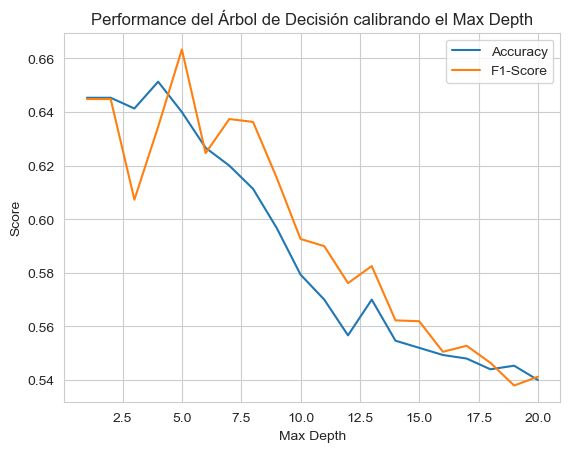

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

plt.plot(max_depth_range, [DT_scores[md]['accuracy'] for md in max_depth_range], label = 'Accuracy')
plt.plot(max_depth_range, [DT_scores[md]['f1_score'] for md in max_depth_range], label = 'F1-Score')
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Performance del Árbol de Decisión calibrando el Max Depth')
plt.legend()
plt.show()

In [ ]:
# Regresión Logística

from sklearn.linear_model import LogisticRegression

iteraciones = [100, 200, 300, 400, 500, 1000, 1500, 2000, 3000, 5000, 10000] # Rango de valores para el parámetro max_iter

LR_scores = {}

for max_iter in iteraciones:

    log_reg = LogisticRegression(max_iter = max_iter, random_state = 42) # Modelo de regresión logística
    log_reg.fit(X_train, y_train) # Entrenamiento del modelo
    y_pred = log_reg.predict(X_test) # Predicciones del modelo
    acc_score = accuracy_score(y_test, y_pred) # Accuracy de las predicciones
    f1 = f1_score(y_test, y_pred) # F1-score de las predicciones
    LR_scores[max_iter] = {'accuracy': acc_score, 'f1_score': f1}

LR_scores

{100: {'accuracy': 0.614, 'f1_score': 0.6106254203093476},
 200: {'accuracy': 0.6173333333333333, 'f1_score': 0.6079234972677595},
 300: {'accuracy': 0.612, 'f1_score': 0.6046195652173912},
 400: {'accuracy': 0.6113333333333333, 'f1_score': 0.5982081323225361},
 500: {'accuracy': 0.6153333333333333, 'f1_score': 0.6061433447098977},
 1000: {'accuracy': 0.6186666666666667, 'f1_score': 0.6055172413793103},
 1500: {'accuracy': 0.61, 'f1_score': 0.5957152729785765},
 2000: {'accuracy': 0.6253333333333333, 'f1_score': 0.6124137931034482},
 3000: {'accuracy': 0.6213333333333333, 'f1_score': 0.6077348066298343},
 5000: {'accuracy': 0.63, 'f1_score': 0.6190803019903912},
 10000: {'accuracy': 0.63, 'f1_score': 0.6190803019903912}}

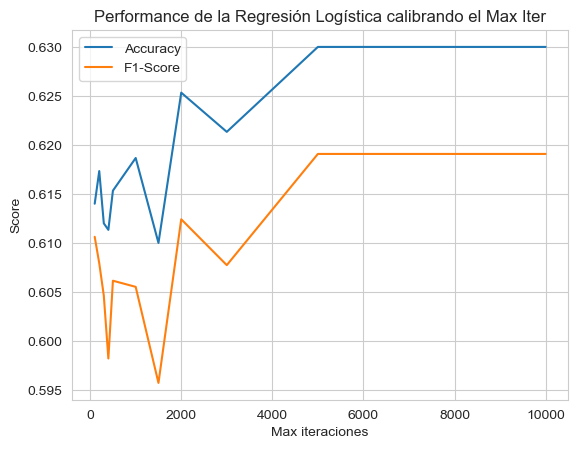

In [282]:
plt.plot(iteraciones, [LR_scores[md]['accuracy'] for md in iteraciones], label = 'Accuracy')
plt.plot(iteraciones, [LR_scores[md]['f1_score'] for md in iteraciones], label = 'F1-Score')
plt.xlabel('Max iteraciones')
plt.ylabel('Score')
plt.title('Performance de la Regresión Logística calibrando el Max Iter')
plt.legend()
plt.show()

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [263]:
# Celda 7


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [264]:
# Celda 8


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [265]:
# Celda 9